In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
#imagae preprocessing
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
# Import Keras layers, models, and optimizers from TensorFlow
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
# import nessary libraries
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import gradio as gr
import keras
from sklearn.preprocessing import OneHotEncoder


2025-09-07 10:50:53.803652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757242254.003658      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757242254.061227      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def split_dataset(input_dir, output_dir, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits datasetrain/vt into al/test sets while preserving directory structure

    Args:
        input_dir: Path to raw dataset (with class subfolders)
        output_dir: Path to save split datasets
        test_size: Proportion for test set (0-1)
        val_size: Proportion for validation set (0-1)
        random_state: Random seed for reproducibility
    """
    # Create output directories
    os.makedirs(os.path.join(output_dir, 'train'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'val'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'test'), exist_ok=True)

    # Get all class folders
    classes = [d for d in os.listdir(input_dir)
               if os.path.isdir(os.path.join(input_dir, d))]

    for class_name in tqdm(classes, desc="Processing classes"):
        # Create class subdirectories in each split
        os.makedirs(os.path.join(output_dir, 'train', class_name), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'val', class_name), exist_ok=True)
        os.makedirs(os.path.join(output_dir, 'test', class_name), exist_ok=True)

        # Get all image files for current class
        class_dir = os.path.join(input_dir, class_name)
        images = [f for f in os.listdir(class_dir)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        # Split into train+temp, then temp into val+test
        train, temp = train_test_split(
            images,
            test_size=(test_size + val_size),
            random_state=random_state
        )
        val, test = train_test_split(
            temp,
            test_size=test_size/(test_size+val_size),
            random_state=random_state
        )

        for phase, files in [('train', train), ('val', val), ('test', test)]:
            for file in files:
                src = os.path.join(class_dir, file)
                dst = os.path.join(output_dir, phase, class_name, file)

                if os.path.exists(src):
                    os.makedirs(os.path.dirname(dst), exist_ok=True)
                    shutil.copy2(src, dst)
                else:
                    print(f"Warning: File not found and skipped: {src}")

        # Print stats per class
        print(f"\n{class_name}:")
        print(f"  Train: {len(train)} images")
        print(f"  Val: {len(val)} images")
        print(f"  Test: {len(test)} images")

    print("\nDataset splitting completed successfully!")
    print(f"Total classes processed: {len(classes)}")

# Example Usage

    # Set your paths here
RAW_DATA_DIR = "/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset" # Original dataset with brand subfolders
SPLIT_DATA_DIR = "/kaggle/working/"  # Where to save the splits

    # Split ratios (test_size + val_size should be < 1)
split_dataset(
        input_dir=RAW_DATA_DIR,
        output_dir=SPLIT_DATA_DIR,
        test_size=0.15,  # 15% test
        val_size=0.15,   # 15% validation
        random_state=42  # For reproducibility
    )

Processing classes:  25%|██▌       | 1/4 [00:32<01:38, 32.70s/it]


ModerateDemented:
  Train: 4524 images
  Val: 970 images
  Test: 970 images


Processing classes:  50%|█████     | 2/4 [01:40<01:46, 53.09s/it]


NonDemented:
  Train: 6720 images
  Val: 1440 images
  Test: 1440 images


Processing classes:  75%|███████▌  | 3/4 [02:42<00:57, 57.46s/it]


VeryMildDemented:
  Train: 6272 images
  Val: 1344 images
  Test: 1344 images


Processing classes: 100%|██████████| 4/4 [03:44<00:00, 56.14s/it]


MildDemented:
  Train: 6272 images
  Val: 1344 images
  Test: 1344 images

Dataset splitting completed successfully!
Total classes processed: 4


In [4]:
Train_path = "/kaggle/working/train"
Test_path  = "/kaggle/working/test"
image_size = (128, 128)
batch_size = 4
num_classes = 4  # Binary: Tumor / No Tumor

In [5]:
# Label dictionary (all lowercase keys)
labels_dict = {
    "nondemented": 0,
    "verymilddemented": 1,
    "milddemented": 2,
    "moderatedemented": 3
}


In [6]:
def show_random_images_cv2(base_dir="dataset", num_images=12, image_size=(250, 128)):
    image_paths = []
    for brand in os.listdir(base_dir):
        brand_folder = os.path.join(base_dir, brand)
        if os.path.isdir(brand_folder):
            for img_file in os.listdir(brand_folder):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                    image_paths.append(os.path.join(brand_folder, img_file))

    selected = random.sample(image_paths, min(num_images, len(image_paths)))

    cols = 4
    rows = (len(selected) + cols - 1) // cols
    plt.figure(figsize=(cols * 3, rows * 3))

    for i, img_path in enumerate(selected):
        img = cv2.imread(img_path)
        if img is None:
            continue  # skip unreadable files
        img = cv2.resize(img, image_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert from BGR to RGB

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(os.path.basename(os.path.dirname(img_path)))

    plt.tight_layout()
    plt.show()

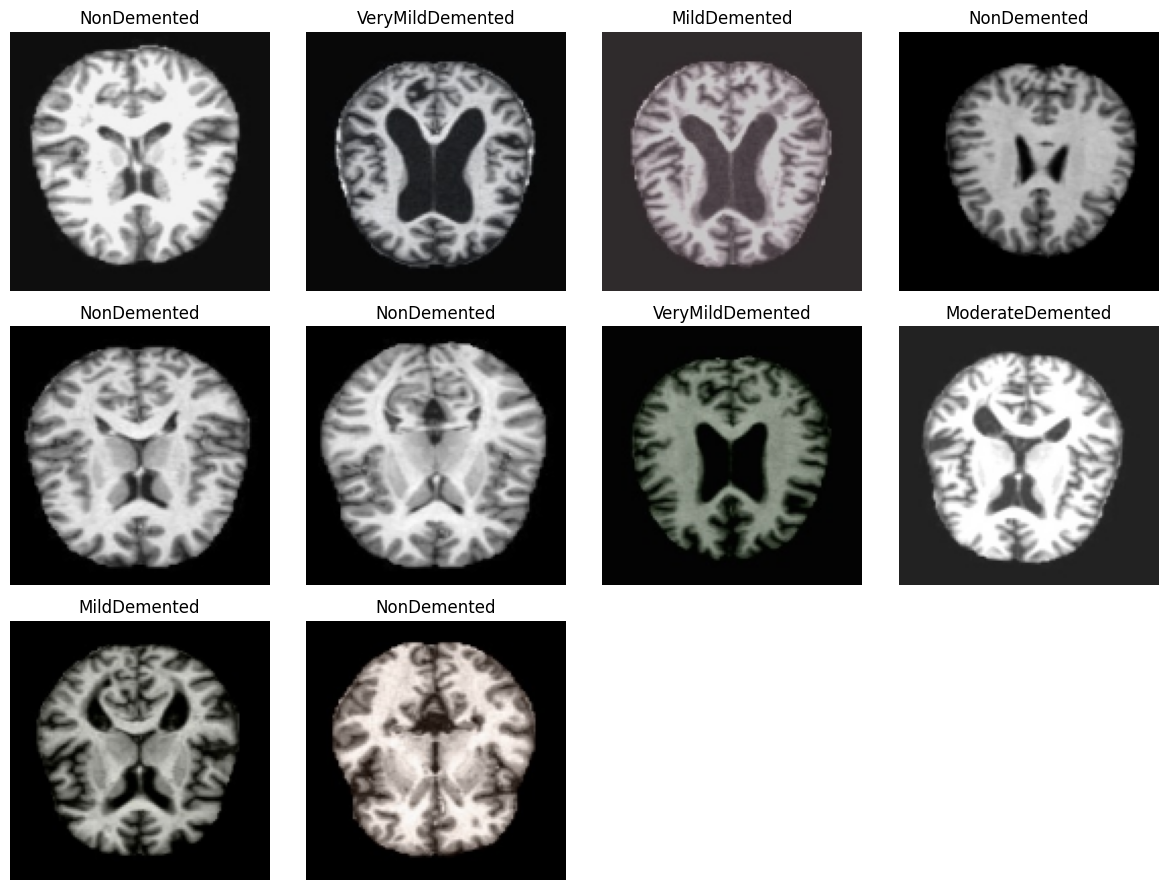

In [7]:
#use the function
show_random_images_cv2(base_dir=Train_path, num_images=10, image_size=image_size)

In [8]:
# =============================================
# 4️⃣ Load Data Function with Optional Augmentation
# =============================================
def load_data_binary(dataset_paths, labels_dict, image_size=(128,128), augment=False):
    X, y = [], []
    for dataset_path in dataset_paths:
        for folder in os.listdir(dataset_path):
            folder_lower = folder.lower()
            if folder_lower not in labels_dict:
                continue
            label = labels_dict[folder_lower]
            folder_path = os.path.join(dataset_path, folder)
            for img_file in os.listdir(folder_path):
                if not img_file.lower().endswith((".png",".jpg",".jpeg")):
                    continue
                img_path = os.path.join(folder_path, img_file)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.resize(img, image_size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label)

                if augment:
                    # Flip horizontal
                    X.append(cv2.flip(img,1))
                    y.append(label)
                    # Rotate ±15 degrees
                    for angle in [15, -15]:
                        M = cv2.getRotationMatrix2D((image_size[0]//2, image_size[1]//2), angle, 1)
                        X.append(cv2.warpAffine(img, M, image_size))
                        y.append(label)

    X = np.array(X, dtype="float32") / 255.0
    y = np.array(y, dtype="float32")
    
    return X, y

In [9]:
X_train, y_train = load_data_binary([Train_path], labels_dict, image_size)
X_test, y_test   = load_data_binary([Test_path], labels_dict, image_size)

In [10]:
print("Training data shape:", X_train.shape, y_train.shape)
print("Test data shape:", X_test.shape, y_test.shape)

Training data shape: (23788, 128, 128, 3) (23788,)
Test data shape: (5098, 128, 128, 3) (5098,)


In [11]:
# =============================================
def attention_block(inputs):
    attention = layers.Conv2D(1, (1,1), activation='sigmoid')(inputs)
    x = layers.Multiply()([inputs, attention])
    return x

def build_binary_cnn(input_shape=(128,128,3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)

    x = attention_block(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(4, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


In [12]:
model = build_binary_cnn(input_shape=(128,128,3))
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

I0000 00:00:1757242510.862093      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16, 1) │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16, 16,    │          0 │ dropout[0][0],    │
│                     │ 128)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32768)     │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  8,388,864 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │      1,028 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,484,165 (32.36 MB)

 Trainable params: 8,483,717 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
from sklearn.preprocessing import OneHotEncoder

# Reshape to 2D
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

# Initialize encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit & transform
y_train = encoder.fit_transform(y_train)
y_test  = encoder.transform(y_test)

print("y_train one-hot shape:", y_train.shape)
print("y_test one-hot shape:", y_test.shape)


y_train one-hot shape: (23788, 4)
y_test one-hot shape: (5098, 4)


In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]


history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    shuffle=True
)

Epoch 1/100


I0000 00:00:1757242527.734074      63 service.cc:148] XLA service 0x7cf124005260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757242527.734970      63 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757242528.211728      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


 13/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2755 - loss: 3.0033

I0000 00:00:1757242532.426384      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


744/744 ━━━━━━━━━━━━━━━━━━━━ 26s 23ms/step - accuracy: 0.4523 - loss: 1.2706 - val_accuracy: 0.6685 - val_loss: 0.7253 - learning_rate: 1.0000e-04
Epoch 2/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6526 - loss: 0.7522 - val_accuracy: 0.7754 - val_loss: 0.5441 - learning_rate: 1.0000e-04
Epoch 3/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7524 - loss: 0.5702 - val_accuracy: 0.8158 - val_loss: 0.4286 - learning_rate: 1.0000e-04
Epoch 4/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8088 - loss: 0.4491 - val_accuracy: 0.8645 - val_loss: 0.3411 - learning_rate: 1.0000e-04
Epoch 5/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8540 - loss: 0.3591 - val_accuracy: 0.8872 - val_loss: 0.2777 - learning_rate: 1.0000e-04
Epoch 6/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8787 - loss: 0.2935 - val_accuracy: 0.8782 - val_loss: 0.2846 - learning_rate: 1.0000e-04
Epoch 7/100
744/744 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - a

In [15]:
# حفظ الموديل بالكامل
model.save("brain_tumor_cnn.keras")
print("Modelsaved successfully!")


Modelsaved successfully!


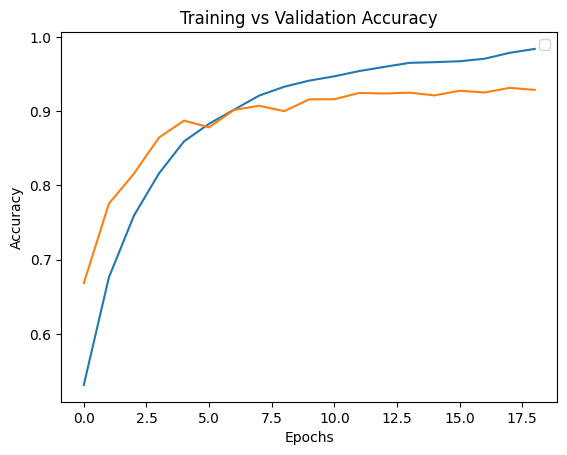

In [16]:
# --- Plot Accuracy ---
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'] )
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()


In [17]:
# load val data 
X_val, y_val = load_data_binary(["/kaggle/working/val"], labels_dict, image_size)
y_val  = y_val.reshape(-1, 1)

y_val = encoder.fit_transform(y_val)


In [18]:


test_loss, test_acc = model.evaluate(X_val, y_val)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9509 - loss: 0.1295
Test Accuracy: 0.9194, Test Loss: 0.1991


In [19]:

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9520 - loss: 0.1326
Test Accuracy: 0.9249, Test Loss: 0.1997


160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Classification Report:
                  precision    recall  f1-score   support

     NonDemented       0.93      0.90      0.91      1440
VeryMildDemented       0.87      0.90      0.89      1344
    MildDemented       0.93      0.92      0.92      1344
ModerateDemented       1.00      1.00      1.00       970

        accuracy                           0.92      5098
       macro avg       0.93      0.93      0.93      5098
    weighted avg       0.93      0.92      0.92      5098



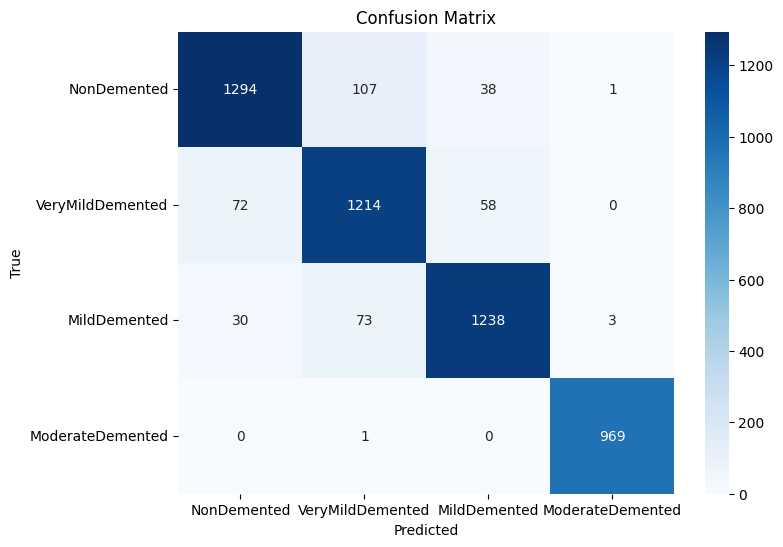

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# If y_test is one-hot encoded, convert to class indices
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.astype(int)

# Predictions: get class indices from softmax probabilities
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names in order of labels
target_names = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [21]:
# Class names in the correct order
class_names = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

def predict_MRI(image):
    # 1️⃣ Preprocess the image
    img = cv2.resize(np.array(image), (128, 128))
    img = img / 255.0                       # normalize
    img = np.expand_dims(img, axis=0)       # add batch dimension

    # 2️⃣ Make prediction
    pred_probs = model.predict(img)[0]      # shape: (4,)

    # 3️⃣ Return as dictionary for Gradio Label output
    return {name: float(prob) for name, prob in zip(class_names, pred_probs)}


In [22]:
import gradio as gr

# Class names in the correct order

interface = gr.Interface(
    fn=predict_MRI,               # your prediction function
    inputs=gr.Image(type="pil"),  # input is a PIL image
    outputs=gr.Label(num_top_classes=4),  # show top 4 classes
    title="Alzheimer MRI Classifier",
    description="Upload a brain MRI image and the model will classify it into one of four Alzheimer's stages.",
    examples=None,                # optional: you can add example images here
)

interface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6aede497954ab6976b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
